# **📊 EXPLORATORY DATA ANALYSIS**

### **IMPORTING MODULES AND CUSTOM FUNCTIONS**

In [9]:
# Accessing the OS
import os
os.makedirs("Plots", exist_ok=True)

import sys
!{sys.executable} -m pip install matplotlib seaborn pandas numpy rich

# Colorfull outputs
import io # can't print colorful .info()
from rich.console import Console
console = Console()

# Custom function for saving plots to specific directory
def dataset_info(df):
    buffer = io.StringIO()
    df.info(buf=buffer)

    console.print(buffer.getvalue())

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

from pathlib import Path

EDA_plots_dir = Path("Plots")
EDA_plots_dir.mkdir(exist_ok=True)

# Cunstom function to save plots
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(EDA_plots_dir / filename, dpi=300, bbox_inches="tight")

### **LOADING DATASET**

In [10]:
data = pd.read_csv(r"..\Processed Datasets\processed_data.csv")
df=pd.DataFrame(data)
df.head(10)


,tag,pattern,response,pattern_length,response_length
0,greeting,Hi,Hello! How can I assist you with Medical Assis...,1,10
1,greeting,Hello,Hello! How can I assist you with Medical Assis...,1,10
2,greeting,Hey,Hello! How can I assist you with Medical Assis...,1,10
3,greeting,Greetings,Hello! How can I assist you with Medical Assis...,1,10
4,cancer_general,What is cancer?,Cancer is a group of diseases characterized by...,3,40
5,cancer_general,Tell me about cancer,Cancer is a group of diseases characterized by...,4,40
6,cancer_general,Explain cancer types,Cancer is a group of diseases characterized by...,3,40
7,cancer_general,How does cancer develop?,Cancer is a group of diseases characterized by...,4,40
8,cancer_types,Tell me about lung cancer,"Cancer types include lung cancer, breast cance...",5,21
9,cancer_types,What are the types of breast cancer?,"Cancer types include lung cancer, breast cance...",7,21


In [11]:
df.head()

,tag,pattern,response,pattern_length,response_length
0,greeting,Hi,Hello! How can I assist you with Medical Assis...,1,10
1,greeting,Hello,Hello! How can I assist you with Medical Assis...,1,10
2,greeting,Hey,Hello! How can I assist you with Medical Assis...,1,10
3,greeting,Greetings,Hello! How can I assist you with Medical Assis...,1,10
4,cancer_general,What is cancer?,Cancer is a group of diseases characterized by...,3,40


In [12]:
console.print(f"Dataset Shape: {df.shape}")
dataset_info(df)

Dataset Shape: (98, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   tag              98 non-null     object
 1   pattern          98 non-null     object
 2   response         98 non-null     object
 3   pattern_length   98 non-null     int64 
 4   response_length  98 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 4.0+ KB

### **ANY MISSING VALUES**

In [13]:
if (df.isnull().sum().any()):
    console.print(f"No. of Missing Values: [bold red]{df.isnull().sum().sum()}")
else:
    console.print("[bold green]NO MISSING VALUE")

NO MISSING VALUE

### **ANY DUPLICATE VALUES**

In [14]:
if(df.duplicated().any()):
    console.print(f"No. of Duplicate Values: [bold red]{df.duplicated().sum()}")
else:
    console.print("[bold green]NO DUPLICATES")

NO DUPLICATES

### **NUMBER OF PATTERN ANALYSIS PER INTENT**

In [15]:
console.print(df['tag'].value_counts())

tag
cancer_symptoms            5
cancer_types               5
cancer_prevention          5
alzheimers_symptoms        5
diabetes_prevention        5
diabetes_types             5
stroke_types               5
stroke_prevention          5
hypertension_prevention    5
alzheimers_types           5
alzheimers_prevention      5
hypertension_types         5
greeting                   4
cancer_general             4
diabetes_general           4
hypertension_general       4
diabetes_symptoms          4
alzheimers_general         4
send_off                   4
stroke_general             4
hypertension_symptoms      3
stroke_symptoms            3
Name: count, dtype: int64

Number of intents: 22 

 ['greeting' 'cancer_general' 'cancer_types' 'cancer_symptoms'
 'cancer_prevention' 'diabetes_general' 'diabetes_types'
 'diabetes_symptoms' 'diabetes_prevention' 'alzheimers_general'
 'alzheimers_types' 'alzheimers_symptoms' 'alzheimers_prevention'
 'hypertension_general' 'hypertension_types' 'hypertension_symptoms'
 'hypertension_prevention' 'stroke_general' 'stroke_types'
 'stroke_symptoms' 'stroke_prevention' 'send_off']

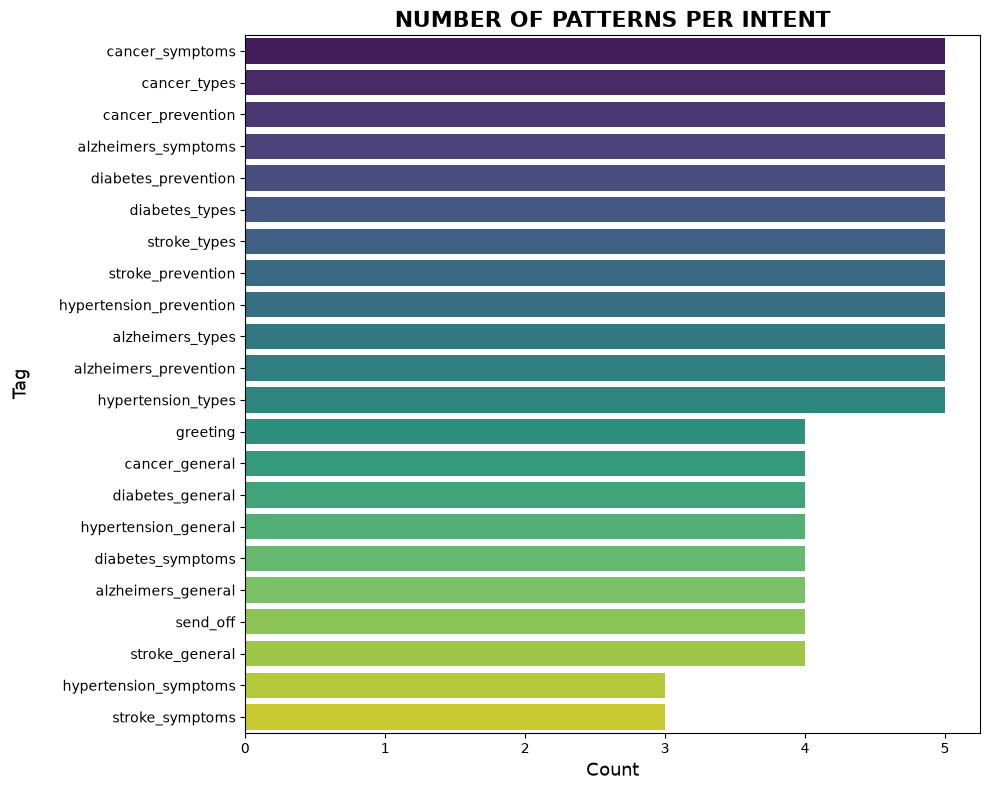

In [16]:
# total number of intents
console.print("Number of intents:", df["tag"].nunique(), "\n\n", df["tag"].unique())
console.print()

palette = sns.color_palette("viridis", n_colors=len(df['tag'].value_counts().index))

plt.figure(figsize=(10,8))
sns.barplot(x=df['tag'].value_counts().values, 
            y=df['tag'].value_counts().index,
            hue=df['tag'].value_counts().index,
            palette=palette)

plt.title("NUMBER OF PATTERNS PER INTENT", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=13)
plt.ylabel("Tag\n", fontsize=13)

save_plot("NUMBER OF PATTERNS PER INTENT")
plt.show()


###  **INTENTS GROUPED BY CETEGORY**

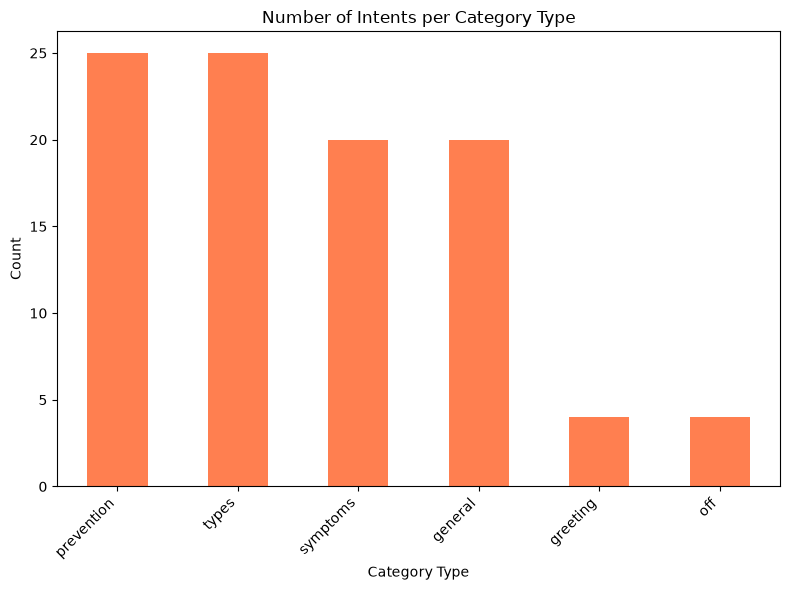

In [22]:
df['intent_type'] = df['tag'].apply(lambda x: x.split('_')[-1])
type_counts = df['intent_type'].value_counts()

plt.figure(figsize=(8, 6))
type_counts.plot(kind='bar', color='coral')
plt.title('Number of Intents per Category Type')
plt.xlabel('Category Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

save_plot('intents_per_category_type.png')
plt.show()
plt.close()

###  **TEST LENGTH ANALYSIS**
**Examining how long the user queries *(patterns)* and bot replies *(responses)* are, using the pre-computed `pattern_length` and `response_length` columns.**

In [17]:
df[['pattern_length', 'response_length']].describe()

,pattern_length,response_length
count,98.000000,98.000000
mean,8.122449,43.561224
std,6.498636,24.176783
min,1.000000,10.000000
25%,4.000000,25.750000
50%,6.000000,35.000000
75%,10.000000,67.750000
max,29.000000,87.000000


tag
alzheimers_general          3.750000
alzheimers_prevention       8.200000
alzheimers_symptoms        22.600000
alzheimers_types            5.000000
cancer_general              3.500000
cancer_prevention           8.000000
cancer_symptoms            18.400000
cancer_types                5.200000
diabetes_general            3.500000
diabetes_prevention         8.000000
diabetes_symptoms          11.750000
diabetes_types              5.200000
greeting                    1.000000
hypertension_general        3.750000
hypertension_prevention     8.400000
hypertension_symptoms      20.666667
hypertension_types          5.200000
send_off                    1.750000
stroke_general              4.000000
stroke_prevention           8.200000
stroke_symptoms            21.666667
stroke_types                5.000000
Name: pattern_length, dtype: float64

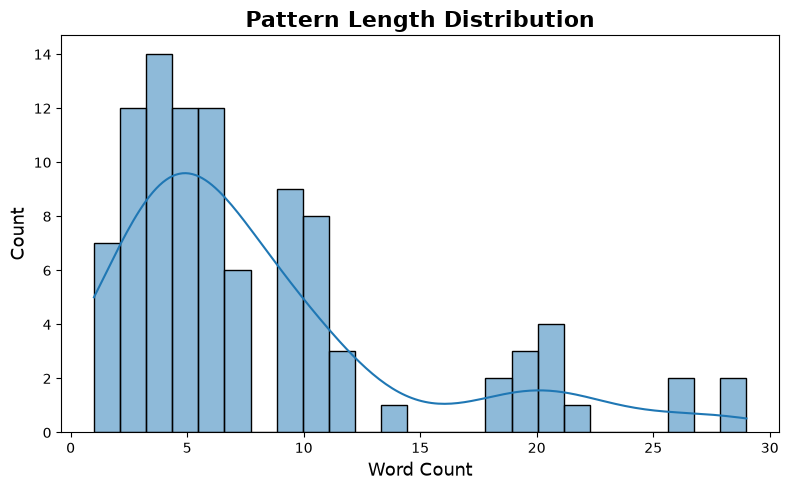

In [18]:
console.print(df.groupby("tag")["pattern_length"].mean())

plt.figure(figsize=(8,5))
sns.histplot(df['pattern_length'], 
             bins=25, 
             kde=True)
plt.title("Pattern Length Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Word Count", fontsize=13)
plt.ylabel("Count", fontsize=13)

save_plot("PATTERN LENGTH DISTRIBUTION")
plt.show()

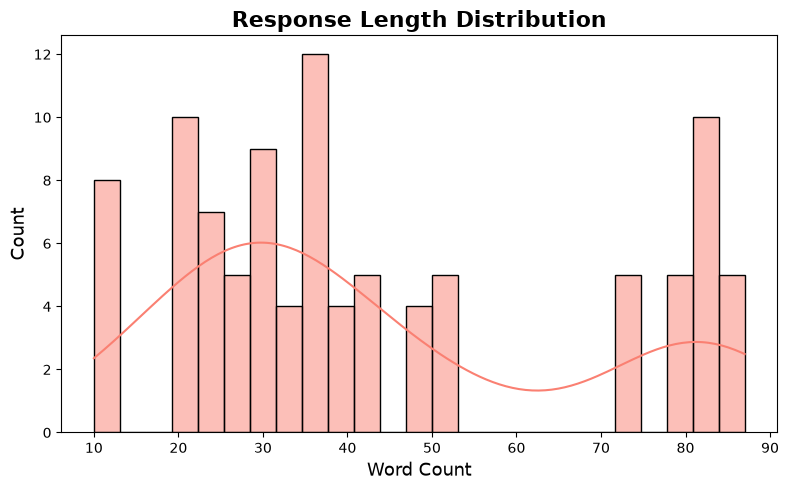

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['response_length'], bins=25, kde=True, color="salmon")
plt.title("Response Length Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Word Count", fontsize=13)
plt.ylabel("Count", fontsize=13)
save_plot("RESPONSE LENGTH DISTRIBUTION")
plt.show()

###  **PATTERN TO RESPONSE RATIO ANALYSIS**
**Examining the balance between user query variations *(pattern)* and bot reply variations *(response)* per intent, using the pre-computed `pattern` and `response` columns.**

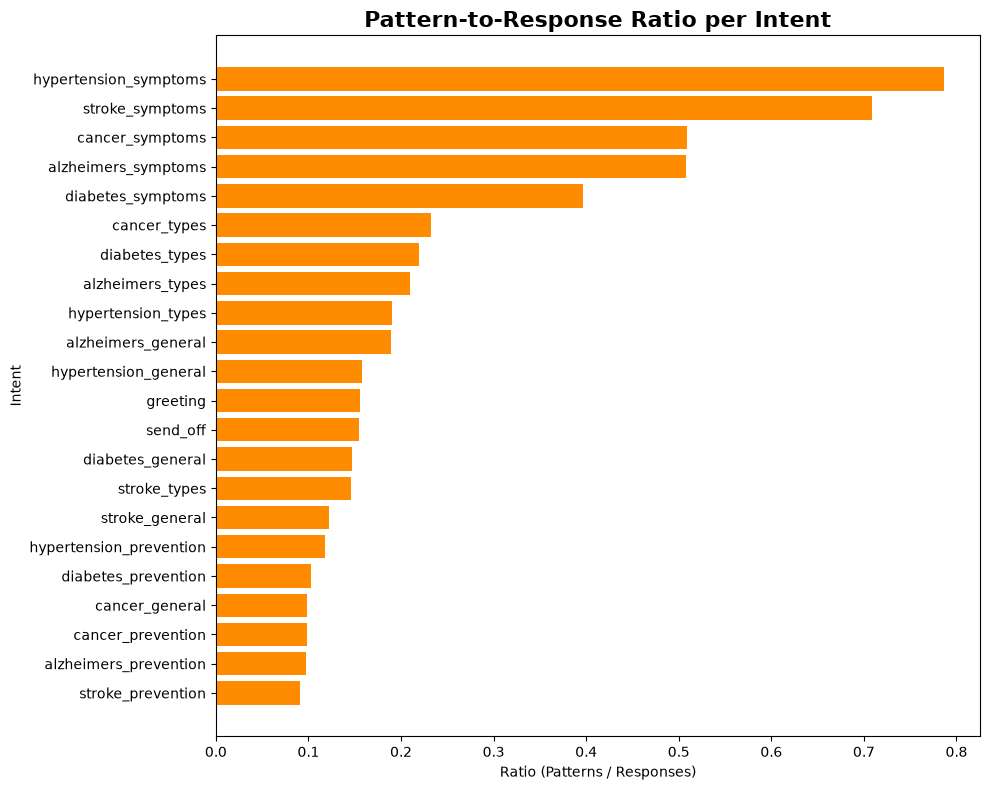

In [21]:
df['num_patterns'] = df['pattern'].apply(len)
df['num_responses'] = df['response'].apply(len)

df['ratio'] = df['num_patterns'] / df['num_responses']

df_sorted = df.sort_values('ratio', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(df_sorted['tag'], df_sorted['ratio'], color='darkorange')
plt.title('Pattern-to-Response Ratio per Intent', fontsize=16, fontweight='bold')
plt.xlabel('Ratio (Patterns / Responses)')
plt.ylabel('Intent')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

### MOST FREQUENT WORDS IN PATTERN
**Finding common vocabulary in user queries**

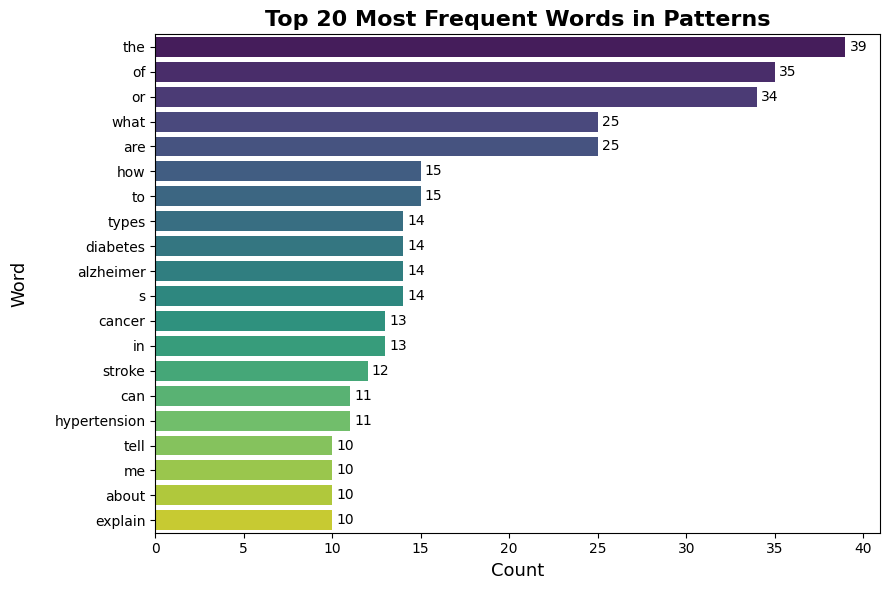

In [ ]:
words = re.findall(r'\b[a-z]+\b', ' '.join(df['pattern']).lower())
top_words = Counter(words).most_common(20)
top_df = pd.DataFrame(top_words, columns=['word', 'count'])

plt.figure(figsize=(9, 6))

palette = sns.color_palette("viridis", n_colors=len(top_df))

ax = sns.barplot(data=top_df, 
                 x='count', 
                 y='word', 
                 palette=palette,
                 hue='word')

# Add count labels beside each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Top 20 Most Frequent Words in Patterns", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=13)
plt.ylabel('Word\n', fontsize=13)

save_plot("TOP 20 MOST FREQUENT WORDS IN PATTERNS")
plt.show()

##  **Summary of Findings**
- Dataset has **98 rows**, **22 intents**, **no missing values** or **duplicates**.
- Intent distribution is slightly **imbalanced** (3–5 examples per intent).
- Average **pattern length** and **response length** noted above.
- **Most frequent words** identified above